# The t-Distribution <hr style="border:2.5px solid #82127cff"></hr>


<b>Lance Marco F. Baltazar</b>
<br>TUPV Computer Engineering CpE-2A

In [174]:
# imports and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [175]:
# load dataset
df = pd.read_csv(r"dataset\transformer-voltage-10-sample.csv",
                 delimiter=",",
                 index_col=["Sample"]
)
df

,Voltage
Sample,
1,118.3
2,119.2
3,119.7
4,119.5
5,120.0
6,120.1
7,120.2
8,120.8
9,121.5


In [176]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10 entries, 1 to 10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Voltage  10 non-null     float64
dtypes: float64(1)
memory usage: 160.0 bytes


In [177]:
# summary of statistics
df.describe()

,Voltage
count,10.000000
mean,120.110000
std,1.050344
min,118.300000
25%,119.550000
50%,120.050000
75%,120.650000
max,121.800000


In [178]:
# t-critical for two-tailed test
alpha = 0.05
n = df['Voltage'].count()

t_critical = stats.t.ppf(1-alpha/2,n-1)
t_critical  

np.float64(2.262157162798205)

In [179]:
# confidence interval
n = df['Voltage'].count()
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

ci_lower, ci_upper = stats.t.interval(
    confidence = 0.95,
    df = n-1,
    loc = mean,
    scale = std / np.sqrt(n)
)

print(f"CI: [{ci_lower:.2f} to {ci_upper:.2f}]")

CI: [119.36 to 120.86]


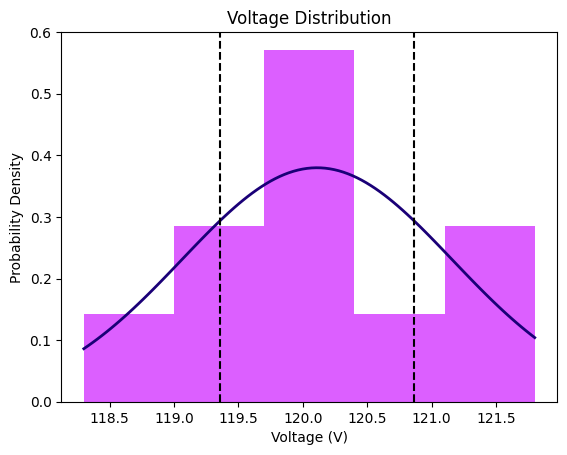

In [180]:
# voltage distribution
mean = df['Voltage'].mean()
std = df['Voltage'].std(ddof=1)

# x-axis
x_min = df['Voltage'].min()
x_max = df['Voltage'].max()

# normal distribution plot
x = np.linspace(x_min, x_max, 100)
p = stats.norm.pdf(x, mean, std)
plt.plot(x, p,
         linewidth=2,
         color="#1A0077")

# histogram
plt.hist(df['Voltage'],
         bins=5,
         density=True,
         alpha=0.8,
         color="#D437FF")

plt.title('Voltage Distribution')
plt.ylabel('Probability Density')
plt.xlabel('Voltage (V)')

# confidence interval
plt.axvline(x=ci_lower,
            color='black',
            linestyle='--')

plt.axvline(x=ci_upper,
            color='black',
            linestyle='--')

plt.show()

# Shoe Inventory

In [181]:
df = pd.read_csv("dataset\shoe-inventory.csv",
                 delimiter=",")
df

<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
C:\Users\lenze\AppData\Local\Temp\ipykernel_16536\2261598205.py:1: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  df = pd.read_csv("dataset\shoe-inventory.csv",


,Size,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,6.0,4,1,3,1,3,3,3,4,3,7,3,0
1,6.5,3,2,0,1,0,0,1,7,2,1,2,1
2,7.0,0,0,1,0,6,4,4,2,3,0,0,0
3,7.5,3,2,3,1,7,0,7,3,4,6,1,1
4,8.0,7,9,7,3,12,2,9,4,7,5,2,6
5,8.5,12,12,8,8,15,9,17,17,6,9,10,6
6,9.0,17,13,13,11,21,22,25,30,26,25,13,10
7,9.5,19,25,27,24,26,33,25,47,31,44,37,26
8,10.0,17,26,26,19,16,31,25,24,23,31,15,20
9,10.5,13,16,22,14,28,19,18,15,19,21,16,10


In [182]:
# (rows, columns)
df.shape

(17, 13)

In [183]:
# mean of size 6
mean_size_6 = df.iloc[0,1:13].mean()  # exclude column index = 13
mean_size_6

np.float64(2.9166666666666665)

In [184]:
# standard deviation of size 6
std_size_6 = df.iloc[0,1:13].std()
std_size_6

np.float64(1.781640374554423)

In [185]:
# size 6 95% CI
n = df.shape[1]-1  # returns 13 in (17,13)

lower_6, upper_6 = stats.t.interval(
    confidence = 0.95,
    df = n-1,
    loc = mean_size_6,
    scale = std_size_6/np.sqrt(n)
)

print(lower_6)
print(upper_6)

1.784666378950379
4.048666954382954


In [186]:
# 95% Confidence Level
mean = df.iloc[:,0:13].mean(axis=1)  # all 16 sizes
std = df.iloc[:,0:13].std(axis=1)

df['ci_lower'], df['ci_upper'] = stats.t.interval(
    confidence = 0.95,
    df = n-1,
    loc = mean,
    scale = std/np.sqrt(n)
)

In [187]:
df

,Size,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,ci_lower,ci_upper
0,6.0,4,1,3,1,3,3,3,4,3,7,3,0,1.941467,4.366225
1,6.5,3,2,0,1,0,0,1,7,2,1,2,1,0.591562,3.485361
2,7.0,0,0,1,0,6,4,4,2,3,0,0,0,0.489314,3.664533
3,7.5,3,2,3,1,7,0,7,3,4,6,1,1,1.849261,5.150739
4,8.0,7,9,7,3,12,2,9,4,7,5,2,6,4.339653,8.121885
5,8.5,12,12,8,8,15,9,17,17,6,9,10,6,8.178995,12.974852
6,9.0,17,13,13,11,21,22,25,30,26,25,13,10,13.580726,22.573120
7,9.5,19,25,27,24,26,33,25,47,31,44,37,26,22.400126,35.061412
8,10.0,17,26,26,19,16,31,25,24,23,31,15,20,17.774698,25.763763
9,10.5,13,16,22,14,28,19,18,15,19,21,16,10,13.897659,20.179264


In [188]:
# fill NAN with 0
df['ci_lower'] = df['ci_lower'].fillna(0)
df['ci_upper'] = df['ci_upper'].fillna(0)

In [189]:
# convert to int and round to 0
df['ci_lower'] = df['ci_lower'].astype(int).round()
df['ci_upper'] = df['ci_upper'].astype(int).round()

In [190]:
# recommended no. of shoe pairs by size
df[['Size','ci_upper']]

,Size,ci_upper
0,6.0,4
1,6.5,3
2,7.0,3
3,7.5,5
4,8.0,8
5,8.5,12
6,9.0,22
7,9.5,35
8,10.0,25
9,10.5,20
